In [1]:
import cv2

# Load the image in grayscale
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)


In [2]:
# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret, thresh = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)
    cv2.imshow(f'Thresholded Image ({threshold_value})', thresh)



In [ ]:
# Display the original image
cv2.imshow('Original Image', img)
cv2.waitKey(0)      
cv2.destroyAllWindows()

In [1]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data, img_as_float
from skimage import exposure

# Step#2: Load moon image
img = data.moon()


In [2]:
# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))


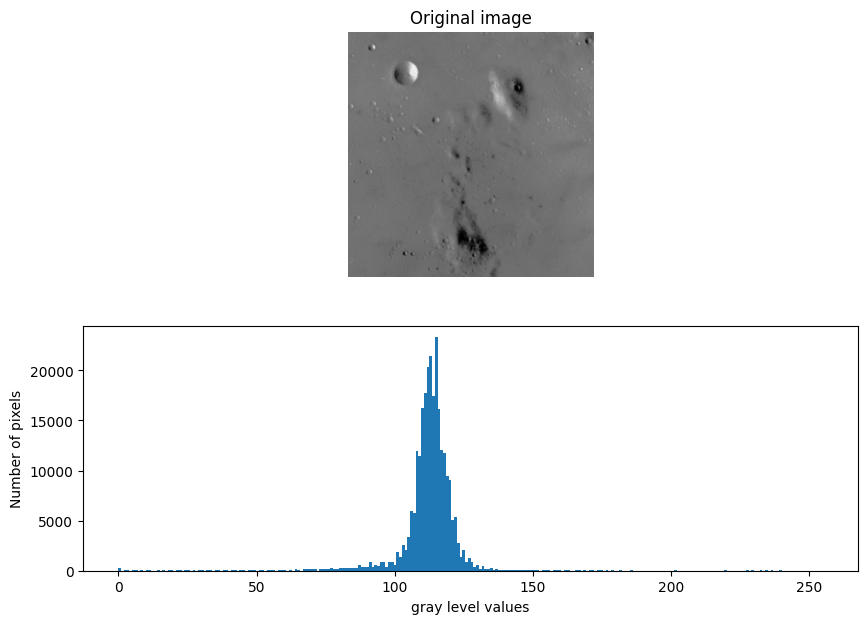

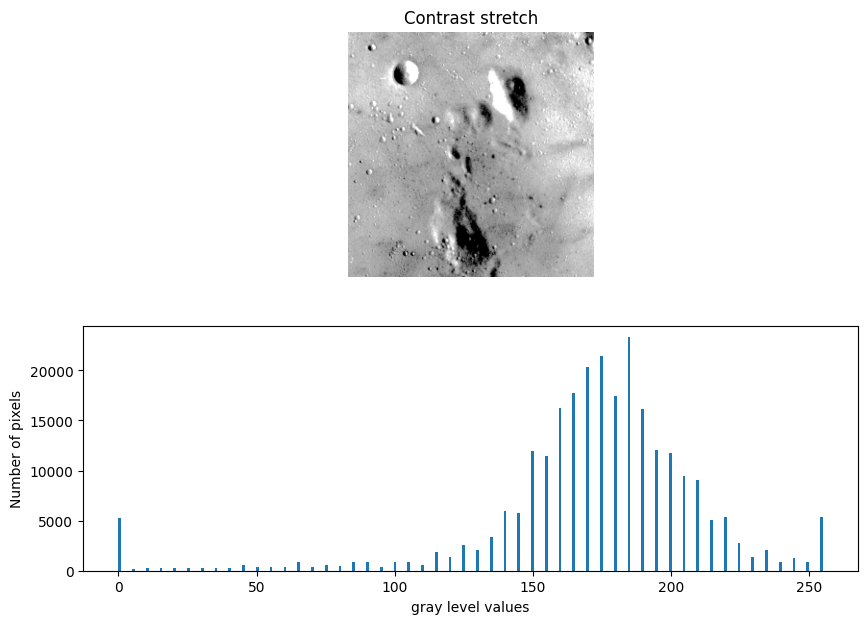

In [3]:
# Step#4: Display the image with its histogram of (step#2)  and (step#3)

fig = plt.figure(figsize=(10, 7)) 
fig.add_subplot(2, 1, 1) 
plt.imshow(img, cmap = 'gray') 
plt.axis('off') 
plt.title('Original image') 
fig.add_subplot(2, 1, 2) 
plt.hist(img.flat, bins = 256, range=(0, 255)) 
plt.xlabel('gray level values') 
plt.ylabel('Number of pixels') 
plt.show() 
fig = plt.figure(figsize=(10, 7)) 
fig.add_subplot(2, 1, 1) 
plt.imshow(img_rescale, cmap = 'gray') 
plt.axis('off') 
plt.title('Contrast stretch')
fig.add_subplot(2, 1, 2) 
plt.hist(img_rescale.flat, bins = 256, range=(0, 255)) 
plt.xlabel('gray level values') 
plt.ylabel('Number of pixels') 
plt.show() 

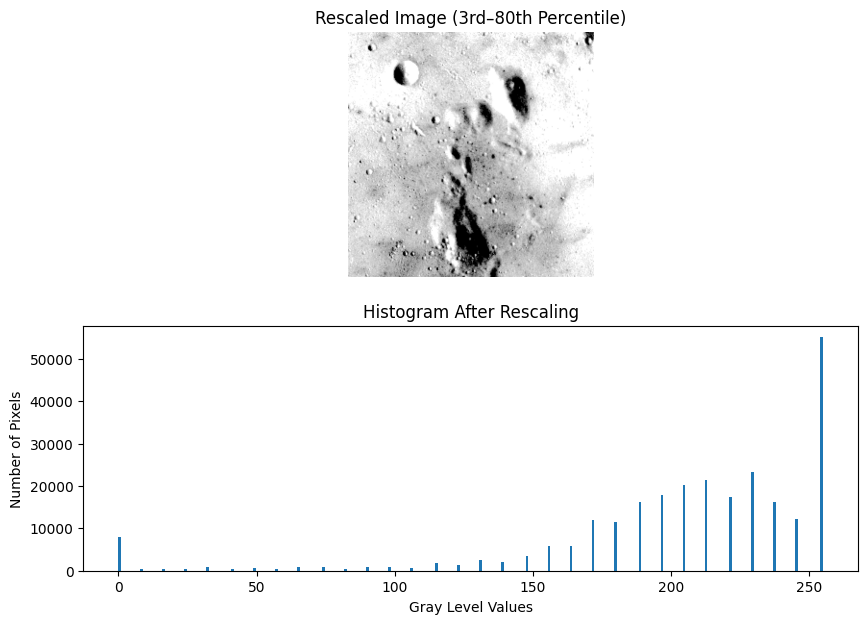

In [9]:
#Task 1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram
img = data.moon()
p3, p80 = np.percentile(img, (3, 80))
img_rescale = exposure.rescale_intensity(img, in_range=(p3, p80))

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap='gray')
plt.axis('off')
plt.title('Rescaled Image (3rd–80th Percentile)')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins=256, range=(0, 255))
plt.xlabel('Gray Level Values')
plt.ylabel('Number of Pixels')
plt.title('Histogram After Rescaling')
plt.show()

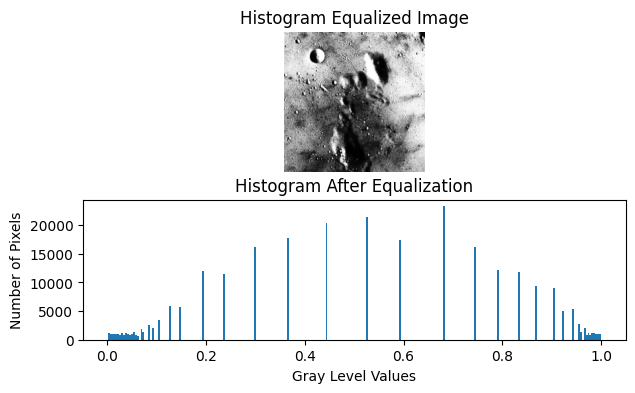

In [10]:
# Task#2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

img = data.moon()
img_eq = exposure.equalize_hist(img)
fig = plt.figure(figsize=(7, 4))

fig.add_subplot(2, 1, 1)
plt.imshow(img_eq, cmap='gray')
plt.axis('off')
plt.title('Histogram Equalized Image')
fig.add_subplot(2, 1, 2)
plt.hist(img_eq.flat, bins=256)
plt.xlabel('Gray Level Values')
plt.ylabel('Number of Pixels')
plt.title('Histogram After Equalization')
plt.show()


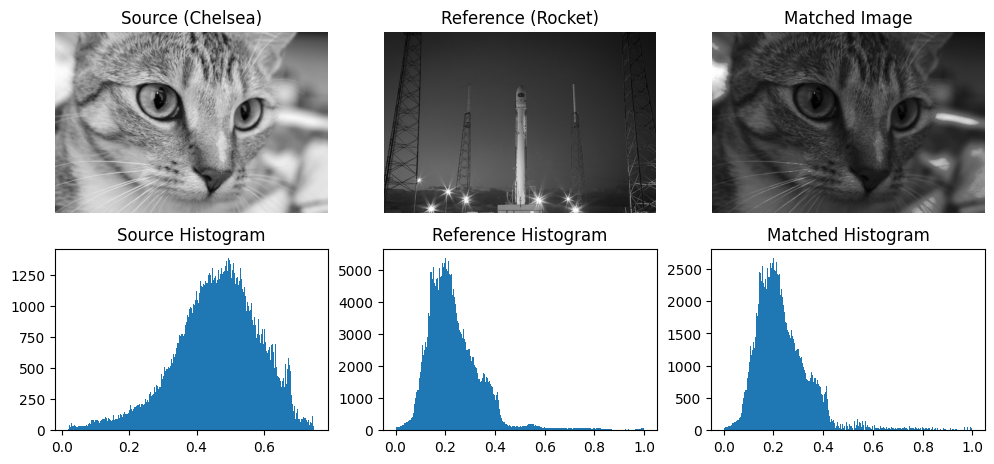

In [13]:
from skimage import data, exposure
import matplotlib.pyplot as plt
from skimage.color import rgb2gray

ref = data.rocket()     
src = data.chelsea()     
ref_gray = rgb2gray(ref)
src_gray = rgb2gray(src)

matched = exposure.match_histograms(src_gray, ref_gray)
fig = plt.figure(figsize=(12, 8))
# Original image
fig.add_subplot(3, 3, 1)
plt.imshow(src_gray, cmap='gray')
plt.axis('off')
plt.title('Source (Chelsea)')
# Reference image
fig.add_subplot(3, 3, 2)
plt.imshow(ref_gray, cmap='gray')
plt.axis('off')
plt.title('Reference (Rocket)')
# Matched image
fig.add_subplot(3, 3, 3)
plt.imshow(matched, cmap='gray')
plt.axis('off')
plt.title('Matched Image')
# Histograms
fig.add_subplot(3, 3, 4)
plt.hist(src_gray.flat, bins=256)
plt.title('Source Histogram')

fig.add_subplot(3, 3, 5)
plt.hist(ref_gray.flat, bins=256)
plt.title('Reference Histogram')

fig.add_subplot(3, 3, 6)
plt.hist(matched.flat, bins=256)
plt.title('Matched Histogram')

plt.show()
